# U1｜機器學習基礎與工作流程

> 60 小時機器學習課程・單元一　|　scikit-learn 為主軸　|

**單元目標**：建立一套可重用的建模工作流程。完成本單元後，學生能用 scikit-learn 完成
`split → 訓練 → 交叉驗證 → 評估` 的完整迴圈，並理解過擬合與資料洩漏的成因。

**學習目標**
1. 說明監督式學習的迴歸與分類任務差異，並複述 ML 七步驟工作流程。
2. 使用 sklearn 的 `fit / predict / score` 三件套訓練第一個模型。
3. 用多項式複雜度示範過擬合，解釋 bias-variance 權衡。
4. 用 `cross_val_score` 取代單次切分，穩健評估模型。
5. 用 `Pipeline` 串接特徵縮放與模型，避免資料洩漏，並建立通用建模模板。

## Part 0｜環境與資料準備

In [22]:
import numpy as np # 數值運算核心套件(陣列,亂數,數學函數)
import pandas as pd # 讀資料和處理表格(DataFrame)
import matplotlib.pyplot as plt # 繪圖套件
import sklearn # 機器學習套件

np.random.seed(112) # 固定亂數種子，目的是為了確保結果可以重現

**載入第一個資料集：California Housing（加州房價）**

這是一個迴歸資料集：用區域的人口統計特徵預測房價中位數。
特徵直覺、量綱差異大（收入是個位數、人口是上千），很適合示範後面的「特徵縮放」。

In [23]:
# 從scikit-learn內建的資料集模組，匯入加州房價資料集
from sklearn.datasets import fetch_california_housing

# 載入加州房價資料集，ad_frame=True:以pandas DataFrame的格式回傳(欄位有名稱，方便操作)
# 若為False則回傳純Numpy陣列
data = fetch_california_housing(as_frame=True)
data.frame # 特徵+目標值合併成完整的DataFrame
data.data # 只顯示特徵
data.target # 只顯示目標值
data.feature_names # 只顯示欄位名稱
data.DESCR # 顯示資料集的說明

df = data.frame
print(f'資料筆數:{len(df)}')
df.head()



資料筆數:20640


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


| 欄位 | 意義 |
|------|------|
| `MedInc` | 區域收入中位數（萬美元） |
| `HouseAge` | 房屋屋齡中位數 |
| `AveRooms` / `AveBedrms` | 平均房間數 / 臥室數 |
| `Population` / `AveOccup` | 區域人口 / 平均居住人數 |
| `Latitude` / `Longitude` | 緯度 / 經度 |
| **`MedHouseVal`** | **目標變數 y**：房價中位數（十萬美元） |

## Part 1｜機器學習導論與工作流程

### 什麼是機器學習
傳統程式是「人寫規則」；機器學習是「從資料中自動學出規則」。給定大量
（輸入 X，答案 y）的例子，模型自己找出 X→y 的對應關係。

三大類型：
- **監督式學習**（本課程主軸）：資料有正確答案 y，學 X→y。
- **非監督式學習**（U5）：資料沒有 y，找資料的結構（分群、降維）。
- **強化學習**：透過與環境互動、獎勵訊號學習（本課程不涵蓋）。

### 監督式學習的兩大任務

| 任務 | 目標 y 型態 | 例子 | 評估指標 |
|------|------------|------|----------|
| **迴歸** | 連續數值 | 房價、報酬率、波動度 | R²、RMSE、MAE |
| **分類** | 離散標籤 | 漲/跌、違約/正常、詐欺/正常 | accuracy、F1、AUC |

本單元以**迴歸**（房價）示範完整流程；分類留待 U3 深入。

### ML 標準工作流程（七步驟）

1. **定義問題與目標變數** — 釐清要預測什麼、是迴歸還分類
2. **資料準備與切分** — 切出訓練集 / 測試集
3. **特徵工程** — 縮放、編碼、建立衍生特徵
4. **選模型與訓練** — `model.fit(X_train, y_train)`
5. **交叉驗證與調參** — 在訓練集內做 CV，選超參數
6. **在測試集評估** — 只在最後做一次，模擬真實表現
7. **部署 / 解釋** — 上線、解讀模型

> ⚠️ **黃金法則**：步驟 5 之前**絕對不能碰測試集**。
> 測試集一旦在訓練/調參過程中被「看過」，評估結果就會過度樂觀。

**資料探索：先看分布與相關性**

In [24]:
# 產生各數值的敘述性統計:筆數，平均數，標準差，最大值和最小值和4分位數
# 用來快速檢查數值間的大小差異和有無極端值或異常
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [25]:
# df.corr() 計算所有欄位兩兩之間的皮爾森相關係數矩陣(範圍 -1 - 1)

# 取出['MedHouseVal']這一欄看與各特徵的相關程度
# sort_values(ascending=False)讓他由高到低排序
# 正值:同向變動，負值:反向變動，但我們會取絕對值，絕對值越大代表關聯性越強(線性關聯)
df.corr()['MedHouseVal'].sort_values(ascending=False)


,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


#### 🧪 練習 1.1
觀察上面的相關係數，寫出你預期**最有預測力**的 2 個特徵，並簡述理由。

最有預測力的2個特徵，分別是

MedInc(收入中位數)，相關達到0.69，收入高的區域房價自然高，其餘特徵與房價的線性相關都偏弱，其中AvgRooms(平均房間數)略有正相關。

## Part 2｜sklearn API 與第一個模型

### Estimator API：三件套
scikit-learn 所有模型共用同一組介面，學會一次、處處適用：

| 方法 | 作用 |
|------|------|
| `model.fit(X, y)` | 用訓練資料**學習** |
| `model.predict(X)` | 對新資料**預測** |
| `model.score(X, y)` | **評分**（迴歸回傳 R²、分類回傳 accuracy） |

換任何模型，通常只需改「建立模型」那一行。

**步驟 1：切出特徵 X 與目標 y，再分割訓練 / 測試集**

In [26]:
# 匯入資料切分工具，把資料隨機分為訓練集和測試集
from sklearn.model_selection import train_test_split

X = df.drop(columns=['MedHouseVal']) # 移除目標欄後剩下的8個欄位，就是我們的特徵
y = df['MedHouseVal'] # 要預測的房價中位數

# 把資料切分成訓練集和測試集各兩份
# test_size=0.2，保留20%當作測試集，80%當作訓練集
# random_state=42，固定亂數種子，確保每一次切分的結果相同
X_train, X_test, y_train, y_test = train_test_split(X, y,
                    test_size=0.2, random_state=42)

print(f'訓練集:{X_train.shape}, 測試集:{X_test.shape}')
print(f'訓練集:{y_train.shape}, 測試集:{y_test.shape}')

訓練集:(16512, 8), 測試集:(4128, 8)
訓練集:(16512,), 測試集:(4128,)


**步驟 2：訓練第一個模型 — 線性迴歸**

In [27]:
# 匯入線性迴歸模型
from sklearn.linear_model import LinearRegression

model = LinearRegression() # 建立模型物件(此時模型還沒有學任何東西)
model.fit(X_train, y_train) # fit:用來訓練模型學習特徵與房價的關係
y_pred = model.predict(X_test) # predict: 對沒看過測試集進行預測

# score:對迴歸任務回傳R2，R2範圍小於1(-1)，我們追求越接近1，代表模型解釋力越好
# R² = 0:模型跟「全部猜平均值」一樣爛,
# R² = 1:完美預測,
# R² < 0:比猜平均還糟(通常代表流程有bug或嚴重過擬合)

print(f'測試集 R2:{round(model.score(X_test, y_test),4)}')
from sklearn.metrics import r2_score
print(f'測試集 R2:{r2_score(y_test, y_pred):.4f}')



測試集 R2:0.5758
測試集 R2:0.5758


**步驟 3：檢視迴歸係數

In [28]:
# model.coef_主要是觀察線性迴歸所學到的各個特徵的係數(權重)
# 解讀:係數是正的，該特徵越大房價就會越高，若為負，但是他會相關性的強度
# 因為目前的資料都還沒有經過特徵縮放，所以係數的大小很容易受到數值之間大小差異而影響
pd.Series(model.coef_, index=X.columns).sort_values()

,0
Longitude,-0.433708
Latitude,-0.419792
AveRooms,-0.123323
AveOccup,-0.003526
Population,-0.000002
HouseAge,0.009724
MedInc,0.448675
AveBedrms,0.783145


#### 🧪 練習 2.1
把模型改成 `KNeighborsRegressor`（k=5）重跑一次，比較 R²。需要改幾行？

In [29]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

print(f'Liner(未縮放)測試集R2:{round(model.score(X_test, y_test),4)}')
print(f'KNN(未縮放)測試集R2:{knn.score(X_test, y_test):.4f}')

# KNN的R2會低的原因是因為KNN這個演算法主要是看數值的距離來找鄰居
# 當特徵沒有縮放的時候，Population(上千)的值會壓過MedInc(個位數)，距離幾乎是由人口欄位決定

Liner(未縮放)測試集R2:0.5758
KNN(未縮放)測試集R2:0.1463


## Part 3｜過擬合、Bias-Variance 與交叉驗證（2h）

### 過擬合 vs 欠擬合
- **欠擬合**：模型太簡單，訓練集與測試集表現都差。
- **過擬合**：模型太複雜，把訓練資料的雜訊也背了起來——
  **訓練分數很高，但測試分數掉下來**。

下面用「多項式次數」當作模擬資料。
為了讓結果更清楚，我們改用一組**合成的一維資料**（特徵只有 1 個、樣本只有 30 筆）。

In [30]:
# 合成資料:產生一條曲線，再加上雜訊(用來示範過擬合)

rng = np.random.RandomState(0) # 建立獨立亂數產生器，固定seed=0
n = 30 # 只產生30筆資料
x = np.sort(rng.rand(n)) # 產生30個[0, 1]的隨機數並進行排序(當作特徵)
y_true = np.cos(1.5  * np.pi * x) # 一條cos的曲線
y_syn = y_true + rng.randn(n) * 0.1 # 加上標準常態雜訊並x0.1，為了要去模擬觀察值
x = x.reshape(-1, 1) # sklearn要求特徵必須要是二維(樣本數, 特徵數)，故轉成(30, 1)

xtr, xte, ytr2, yte2 = train_test_split(x, y_syn, test_size=0.4, random_state=0)
print(f'合成資料:訓練:{xtr.shape[0]}, 筆 / 測試:{xte.shape[0]}, 筆')

合成資料:訓練:18, 筆 / 測試:12, 筆


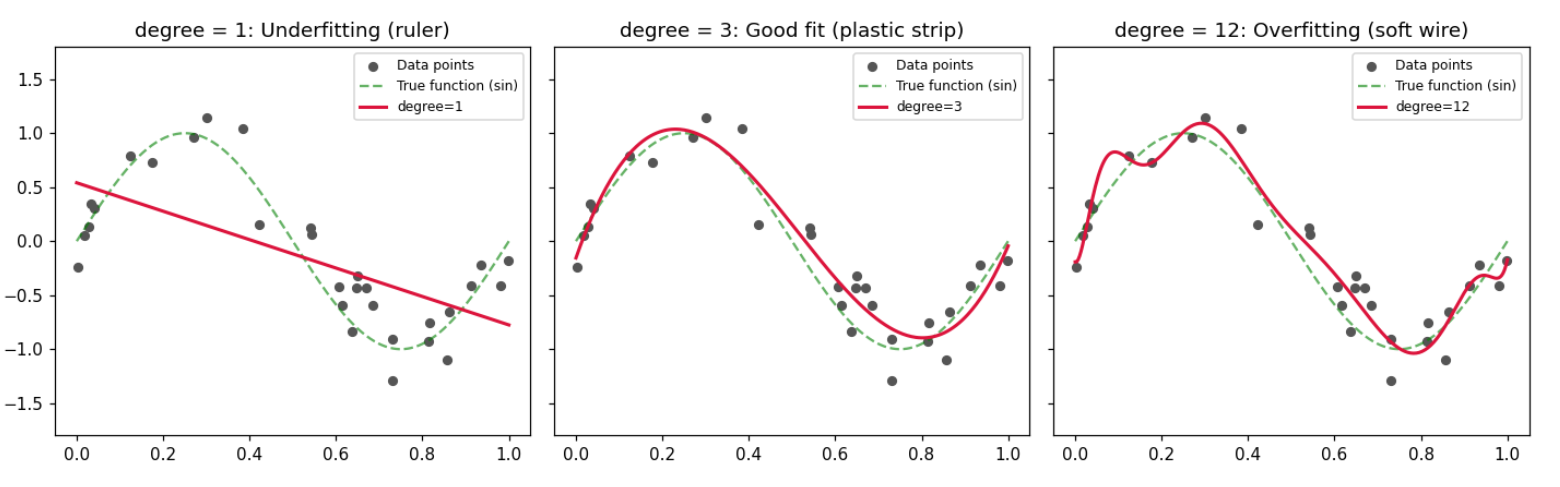

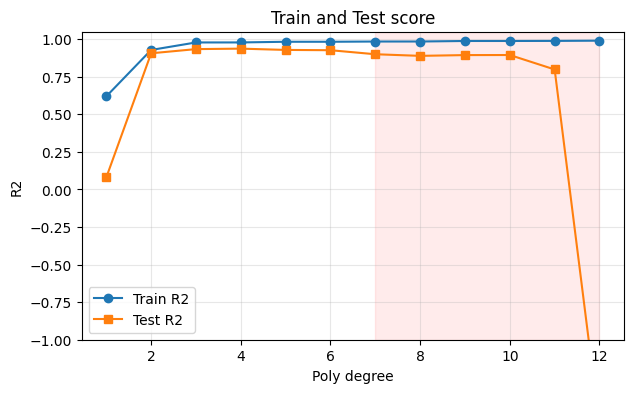

In [31]:
# 匯入工具
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 安排12個考生來學習同一資料
degrees = range(1, 13)
# 準備兩本空白的成績冊，train_scores記平時成績的，test_scores記期末考成績
train_scores, test_scores = [],[]

# 每個考生輪流上場
for d in degrees:
  m = make_pipeline(PolynomialFeatures(d), LinearRegression())
  # 讓學生讀18筆讀書用的資料
  m.fit(xtr, ytr2)
  # 考兩場試，第一場是拿讀過的18筆來考他，開書考，理論上會考好
  # 第二場拿藏起來的12筆來考他，閉書考
  train_scores.append(m.score(xtr, ytr2))
  test_scores.append(m.score(xte, yte2))

# 預期現象，次數太少，訓練和測試都很低 Underfitting
# 次數適中，兩者都很高且很接近 最佳解
# 次數太大，訓練好高，但測試崩盤 Overfitting

plt.figure(figsize=(7, 4))

plt.plot(list(degrees), train_scores, 'o-', label='Train R2')
plt.plot(list(degrees), test_scores, 's-', label='Test R2')

plt.axvspan(7, 12, color='r', alpha=0.08)

plt.ylim(-1, 1.05)
plt.xlabel('Poly degree')
plt.ylabel('R2')
plt.title('Train and Test score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 📈 這張圖怎麼看

這是一張 **模型複雜度（多項式次數）vs 表現（R²）** 的過擬合診斷圖。

**兩條線**
- **Train R2（圓點線）**：模型在「看過的」訓練資料上的表現。
- **Test R2（方點線）**：模型在「沒看過的」測試資料上的表現 —— 這才是真正的泛化能力。
- X 軸：多項式次數 = 複雜度（越右越有彈性）；Y 軸：R²（越接近 1 越好）。

**從左到右三個區域**

| 區域 | 現象 | 診斷 |
|------|------|------|
| **左側（低次數 1~2）** | 兩條線都低、且貼在一起 | **欠擬合**：模型太簡單，連訓練都學不好（高 bias） |
| **中間（甜蜜點）** | Test R2 達到最高、兩線都高且接近 | **最佳複雜度**：該選這裡 |
| **右側紅區（7~12）** | Train R2 幾乎衝到 1，但 Test R2 崩落（甚至變負） | **過擬合**：把雜訊也背了起來（高 variance） |

**核心：剪刀差**
- 一開始兩線一起上升 → 增加複雜度確實有幫助。
- 過了甜蜜點後兩線**分岔（像剪刀張開）** → 訓練還在漲、測試卻往下掉。
- 這個分岔就是**過擬合的訊號**：訓練分數高 ≠ 真本事，要看測試分數。

> **一句話**：不要追求「訓練分數越高越好」，而要選 **Test R2 最高**、也就是兩線開始分岔之前的複雜度。
> 右側的過擬合，之後可用**正規化（Ridge/Lasso, U2）**壓制；找甜蜜點則靠**交叉驗證**更穩健。

### Bias-Variance 權衡
上圖三個區域：
- **左側（低次數）**：高 **bias**，兩條線都不高 → 欠擬合。
- **中間**：剛好，測試分數最高 → 最佳複雜度。
- **右側紅區（高次數）**：高 **variance**，訓練近完美但測試崩盤 → 過擬合。

好模型要在 bias 與 variance 之間取得平衡，而不是一味追求訓練分數。

### 為什麼需要交叉驗證
單一次 train/test 切分，分數會隨「剛好切到哪些樣本」而上下波動。
**K 折交叉驗證**把資料切成 K 份、輪流當測試折，取平均，評估更穩定。

In [41]:
from sklearn.model_selection import cross_val_score, KFold

# n_splites = 10，代表將資料切成10份，輪流當測試折(訓練9份，測試1份)
# shuffle=True，切分之前先打亂資料順序(避免原始排序造成誤差)
# random_state=42 固定打亂方式，可重現
cv = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(LinearRegression(), X_train, y_train, cv=cv, scoring='r2')
print(f'每折R2:{scores.round(3)}')
print(f'平均R2:{scores.mean():.3f}')


每折R2:[0.604 0.614 0.63  0.577 0.62  0.652 0.588 0.613 0.62  0.594]
平均R2:0.611


#### 🧪 練習 3.1
把 `n_splits` 改成 5，平均與標準差怎麼變？折數越多有什麼利弊？

In [42]:
from sklearn.model_selection import cross_val_score, KFold

# n_splites = 10，代表將資料切成10份，輪流當測試折(訓練9份，測試1份)
# shuffle=True，切分之前先打亂資料順序(避免原始排序造成誤差)
# random_state=42 固定打亂方式，可重現
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(LinearRegression(), X_train, y_train, cv=cv, scoring='r2')
print(f'每折R2:{scores.round(3)}')
print(f'平均R2:{scores.mean():.3f}')


每折R2:[0.61  0.604 0.635 0.601 0.607]
平均R2:0.611


折數增加 → 每折的訓練資料更多，平均通常更穩；但每折測試樣本變少， 單折分數的波動可能讓標準差未必單調下降。代價是計算成本上升（要訓練 10 次）

## Part 4｜特徵縮放、Pipeline 與評估指標

### 為什麼要特徵縮放
距離型與正規化模型（KNN、SVM、Ridge/Lasso）對特徵量綱敏感。
若不縮放，數值大的特徵會主導結果（回想 練習 2.1 的 KNN）。
> 樹模型（U4）則**不需要**縮放——這個對比 U4 會再強調。

**縮放 vs 未縮放的 KNN ——

In [45]:
# 匯入標準化的特徵縮放器
from sklearn.preprocessing import StandardScaler # 幫忙把特徵轉成平均0和標準差1
from sklearn.neighbors import KNeighborsRegressor

knn_raw = KNeighborsRegressor() # 未縮放，直接使用原始特徵
knn_scaled = make_pipeline(StandardScaler(), KNeighborsRegressor()) # 先對特徵進行縮放，再用KNN串成一條管線

r_raw = cross_val_score(knn_raw, X_train, y_train, cv=cv, scoring='r2').mean()
r_scaled = cross_val_score(knn_scaled, X_train, y_train, cv=cv, scoring='r2').mean()

print(f'未縮放 KNN 平均 R2:{r_raw:.3f}')
print(f'縮放 KNN 平均 R2:{r_scaled:.3f}')

未縮放 KNN 平均 R2:0.125
縮放 KNN 平均 R2:0.684


In [50]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X_train)
x_scaled_df = pd.DataFrame(x_scaled, columns=X_train.columns, index=X_train.index)

X_train.head()
# print(f'縮放前的資料集:{X_train}')
# print(f'縮放後的資料集:{x_scaled}')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [51]:
x_scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


### 評估指標總覽

**迴歸**
| 指標 | 意義 | 單位 |
|------|------|------|
| MAE | 平均絕對誤差 | 與 y 同單位、好解讀 |
| MSE / RMSE | （均）方誤差 | RMSE 與 y 同單位、對大誤差敏感 |
| R² | 解釋變異比例 | 0~1，越高越好 |

**分類**（預告 U3）：accuracy、precision、recall、F1、ROC-AUC。

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = knn_scaled.fit(X_train, y_train).predict(X_test)

print(f'MAE:{mean_absolute_error(y_test, y_pred):.3f}')
print(f'MSE:{mean_squared_error(y_test, y_pred):.3f}')
print(f'RMSE:{mean_squared_error(y_test, y_pred) ** 0.5:.3f}')
print(f'R2:{r2_score(y_test, y_pred):.3f}')

MAE:0.446
MSE:0.432
RMSE:0.658
R2:0.670


#### 🎯 綜合練習
自選 `Ridge` 或 `KNeighborsRegressor`，建立一條 `StandardScaler → 模型` 的 Pipeline，
**在訓練集（`X_train, y_train`）上**用 5 折交叉驗證同時報告**平均 R² 與 RMSE**，
最後寫 3 行結論說明縮放是否有幫助。（測試集不參與本題——它已在上一格用掉了。）